## Orbit #06326

Using v23 l1a

## Animation

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML, display
from pathlib import Path

# -----------------------------
# User parameters
# -----------------------------
nc_path = r"Z:\socfiles\l1a\remap_alt\awe_l1a_q20_2025003T0615_06326_v23_remap85.nc"

out_dir = Path("AWE/06326/remap85")
out_dir.mkdir(parents=True, exist_ok=True)

TARGET_LAT = 41.934
TARGET_LON = -111.421
R_MAX_KM = 200.0

VMIN = 3
VMAX = 14

t_start = 900
t_end   = 950  # inclusive

# -----------------------------
# Load dataset
# -----------------------------
ds = Dataset(nc_path, "r")

rad_all = ds.variables["Radiance"][:]       # (time, y, x)
lat_all = ds.variables["Latitude"][:]       # (time, y, x)
lon_raw = ds.variables["Longitude"][:]      # (time, y, x)

# Normalize longitudes to [-180, 180]
lon_all = ((lon_raw + 180) % 360) - 180

nt = rad_all.shape[0]
print(f"Radiance shape: {rad_all.shape}")

# Ensure frame range is valid
t_start = max(0, t_start)
t_end = min(t_end, nt - 1)
frames = list(range(t_start, t_end + 1))

# -----------------------------
# {R_MAX_KM} km → degree conversion
# -----------------------------
km_per_deg_lat = 111.0
km_per_deg_lon = 111.0 * np.cos(np.deg2rad(TARGET_LAT))

dlat_deg = R_MAX_KM / km_per_deg_lat
dlon_deg = R_MAX_KM / km_per_deg_lon

lat_min = TARGET_LAT - dlat_deg
lat_max = TARGET_LAT + dlat_deg
lon_min = TARGET_LON - dlon_deg
lon_max = TARGET_LON + dlon_deg

print(f"Map extent (approx 500 km box):")
print(f"   lat: [{lat_min:.2f}, {lat_max:.2f}]")
print(f"   lon: [{lon_min:.2f}, {lon_max:.2f}]")

# -----------------------------
# Precompute per-frame data (inside the box)
# -----------------------------
lon_list = []
lat_list = []
rad_list = []

for t in frames:
    lat_t = lat_all[t, :, :]
    lon_t = lon_all[t, :, :]
    rad_t = rad_all[t, :, :]

    # Flatten
    lat_flat = lat_t.ravel()
    lon_flat = lon_t.ravel()
    rad_flat = rad_t.ravel()

    # Valid mask
    valid = ~np.isnan(lat_flat) & ~np.isnan(lon_flat) & ~np.isnan(rad_flat)

    # Keep only pixels within the 500 km box (lat/lon window)
    inside_box = (
        (lat_flat >= lat_min) & (lat_flat <= lat_max) &
        (lon_flat >= lon_min) & (lon_flat <= lon_max)
    )

    mask = valid & inside_box

    lon_v = lon_flat[mask]
    lat_v = lat_flat[mask]
    rad_v = rad_flat[mask]

    #print(f"Frame {t}: {lon_v.size} pixels inside box")

    lon_list.append(lon_v)
    lat_list.append(lat_v)
    rad_list.append(rad_v)

# -----------------------------
# Set up figure & projection
# -----------------------------
proj = ccrs.LambertAzimuthalEqualArea(
    central_longitude=TARGET_LON,
    central_latitude=TARGET_LAT,
)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=proj)

# Zoom to the {R_MAX_KM} km box (extent in PlateCarree coords)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Initial scatter (if first frame has no points, use empty)
if len(lon_list[0]) == 0:
    scat = ax.scatter(
        [], [],
        c=[],
        s=5,
        cmap="gray",
        vmin=VMIN,
        vmax=VMAX,
        transform=ccrs.PlateCarree(),
    )
else:
    scat = ax.scatter(
        lon_list[0],
        lat_list[0],
        c=rad_list[0],
        s=5,
        cmap="gray",      # grayscale, brighter = higher
        vmin=VMIN,
        vmax=VMAX,
        transform=ccrs.PlateCarree(),
    )

# Mark target point
ax.plot(
    TARGET_LON,
    TARGET_LAT,
    "rx",
    markersize=10,
    mew=2,
    transform=ccrs.PlateCarree(),
)

cbar = plt.colorbar(scat, ax=ax, label="Radiance")

title = ax.set_title(f"AWE Radiance – Frame {frames[0]}")

plt.tight_layout()

# -----------------------------
# Animation function
# -----------------------------
def update(i):
    lon_v = lon_list[i]
    lat_v = lat_list[i]
    rad_v = rad_list[i]

    if lon_v.size == 0:
        scat.set_offsets(np.empty((0, 2)))
        scat.set_array(np.array([]))
    else:
        offsets = np.column_stack((lon_v, lat_v))
        scat.set_offsets(offsets)
        scat.set_array(rad_v)

    title.set_text(
        f"AWE Radiance – Frame {frames[i]}\n"
        f"Within ~{R_MAX_KM} km of ({TARGET_LAT}°, {TARGET_LON}°)"
    )
    return scat, title

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=200,  # ms between frames
    blit=False,
)

# -----------------------------
# Show animation inline (HTML5 video)
# -----------------------------
plt.close(fig)  # avoid duplicate static figure
display(HTML(anim.to_html5_video()))

# -----------------------------
# Save as MP4 (requires ffmpeg installed)
# -----------------------------

mp4_filename = out_dir / "awe_radiance_200km_box.mp4"
writer = FFMpegWriter(fps=4, bitrate=1800)
anim.save(mp4_filename, writer=writer)
print(f"Saved animation to {mp4_filename}")

# Close dataset
ds.close()


Radiance shape: (1873, 300, 300)
Map extent (approx 500 km box):
   lat: [40.13, 43.74]
   lon: [-113.84, -109.00]


Saved animation to AWE\06326\remap85\awe_radiance_200km_box.mp4


## Interpolate

In [6]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML, display

# -----------------------------
# Regular lat/lon grid for interpolation
# -----------------------------
N_LAT = 200   # number of grid points in latitude
N_LON = 200   # number of grid points in longitude

grid_lons = np.linspace(lon_min, lon_max, N_LON)
grid_lats = np.linspace(lat_min, lat_max, N_LAT)
grid_lon2d, grid_lat2d = np.meshgrid(grid_lons, grid_lats)

def interpolate_frame(lon_v, lat_v, rad_v):
    """
    Interpolate scattered points (lon_v, lat_v, rad_v)
    onto the regular grid (grid_lon2d, grid_lat2d).
    """
    if lon_v.size == 0:
        return np.full_like(grid_lon2d, np.nan, dtype=float)

    points = np.column_stack((lon_v, lat_v))

    # linear interpolation
    grid_rad = griddata(
        points,
        rad_v,
        (grid_lon2d, grid_lat2d),
        method="linear",
    )

    # fill remaining NaNs with nearest neighbor
    mask_nan = np.isnan(grid_rad)
    if np.any(mask_nan):
        grid_rad_nn = griddata(
            points,
            rad_v,
            (grid_lon2d, grid_lat2d),
            method="nearest",
        )
        grid_rad[mask_nan] = grid_rad_nn[mask_nan]

    return grid_rad

# -----------------------------
# Precompute interpolated grids for all frames
# -----------------------------
grid_rad_list = []
for lon_v, lat_v, rad_v in zip(lon_list, lat_list, rad_list):
    grid_rad = interpolate_frame(lon_v, lat_v, rad_v)
    grid_rad_list.append(grid_rad)

# -----------------------------
# Set up figure and projection
# -----------------------------
proj = ccrs.LambertAzimuthalEqualArea(
    central_longitude=TARGET_LON,
    central_latitude=TARGET_LAT,
)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=proj)

# Zoom to the box (extent in PlateCarree coords)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Initial image
grid_rad0 = grid_rad_list[0]

img = ax.imshow(
    grid_rad0,
    origin="lower",
    extent=[lon_min, lon_max, lat_min, lat_max],
    transform=ccrs.PlateCarree(),
    cmap="gray",
    vmin=VMIN,
    vmax=VMAX,
)

# Mark target point
ax.plot(
    TARGET_LON,
    TARGET_LAT,
    "rx",
    markersize=10,
    mew=2,
    transform=ccrs.PlateCarree(),
)

cbar = plt.colorbar(img, ax=ax, label="Radiance")

title = ax.set_title(f"AWE Radiance - Frame {frames[0]}")

plt.tight_layout()

# -----------------------------
# Animation function
# -----------------------------
def update(i):
    grid_rad = grid_rad_list[i]
    img.set_data(grid_rad)

    title.set_text(
        f"AWE Radiance - Frame {frames[i]}\n"
        f"Within ~{R_MAX_KM} km of ({TARGET_LAT}°, {TARGET_LON}°)"
    )
    return img, title

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=200,  # ms between frames
    blit=False,
)

# -----------------------------
# Show animation inline (HTML5 video)
# -----------------------------
plt.close(fig)  # avoid duplicate static figure
display(HTML(anim.to_html5_video()))

# -----------------------------
# Save as MP4 (requires ffmpeg installed)
# -----------------------------
mp4_filename = out_dir / "awe_radiance_200km_box_interpolated.mp4"
writer = FFMpegWriter(fps=4, bitrate=1800)
anim.save(mp4_filename, writer=writer)
print(f"Saved animation to {mp4_filename}")


Saved animation to AWE\06326\remap85\awe_radiance_200km_box_interpolated.mp4


## Save whole images

In [7]:
import os
import matplotlib.pyplot as plt

# -----------------------------
# Save interpolated images (content only)
# -----------------------------
output_dir = out_dir / "awe_radiance_200km_box_interpolated_frames"
os.makedirs(output_dir, exist_ok=True)

for i, grid_rad in enumerate(grid_rad_list):
    frame_id = frames[i]

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(
        grid_rad,
        origin="lower",
        cmap="gray",
        vmin=VMIN,
        vmax=VMAX,
    )
    ax.axis("off")

    out_path = os.path.join(output_dir, f"awe_interp_{frame_id:04d}.png")
    fig.savefig(out_path, bbox_inches="tight", pad_inches=0, dpi=208)
    plt.close(fig)

print(f"Saved {len(grid_rad_list)} interpolated frames to '{output_dir}'")


Saved 51 interpolated frames to 'AWE\06326\remap85\awe_radiance_200km_box_interpolated_frames'


## Save Cropped Images

In [8]:
import os
import imageio.v3 as iio
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Input/output folders
# -----------------------------
input_dir = out_dir / "awe_radiance_200km_box_interpolated_frames"
output_dir = out_dir / "awe_radiance_200km_box_interpolated_frames_cropped"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# Crop region
# -----------------------------
x_start, x_end = 320-160, 320+160   # columns
y_start, y_end = 320-128, 320+128   # rows

# -----------------------------
# Process each image
# -----------------------------
files = sorted([f for f in os.listdir(input_dir) if f.endswith(".png")])

for fname in files:
    img = iio.imread(os.path.join(input_dir, fname))

    # Expect img shape 
    cropped = img[y_start:y_end, x_start:x_end]

    # Save cropped 
    out_path = os.path.join(output_dir, fname)
    iio.imwrite(out_path, cropped)

print(f"Cropped {len(files)} images → saved to '{output_dir}'")


Cropped 51 images → saved to 'AWE\06326\remap85\awe_radiance_200km_box_interpolated_frames_cropped'


## Multiple ROIs

Using ROIs:
  ROI_14: x=20:140, y=96:216

ROI: ROI_14
  X_SLICE: slice(20, 140, None)
  Y_SLICE: slice(96, 216, None)
  Found 51 PNG image files in AWE\06326\remap85\awe_radiance_200km_box_interpolated_frames_cropped
  Overlay output directory: AWE\06326\remap85\awe_radiance_200km_box_interpolated_frames_cropped\overlays_crests_phase\ROI_14
  Saved: AWE\06326\remap85\awe_radiance_200km_box_interpolated_frames_cropped\overlays_crests_phase\ROI_14\crest_relative_amplitude_evolution.npy
  Saved: AWE\06326\remap85\awe_radiance_200km_box_interpolated_frames_cropped\overlays_crests_phase\ROI_14\crest_relative_amplitude_evolution.csv


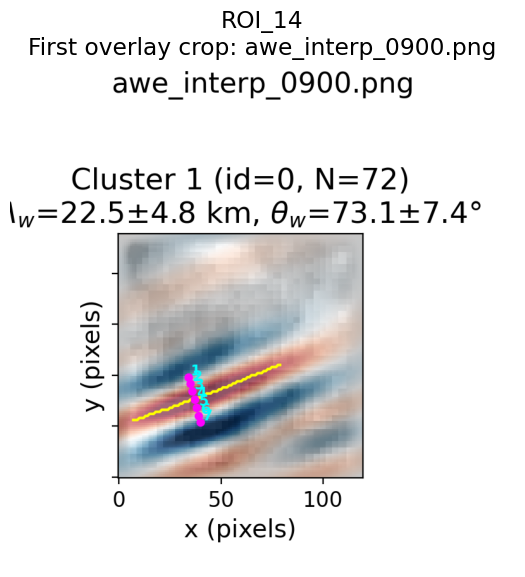

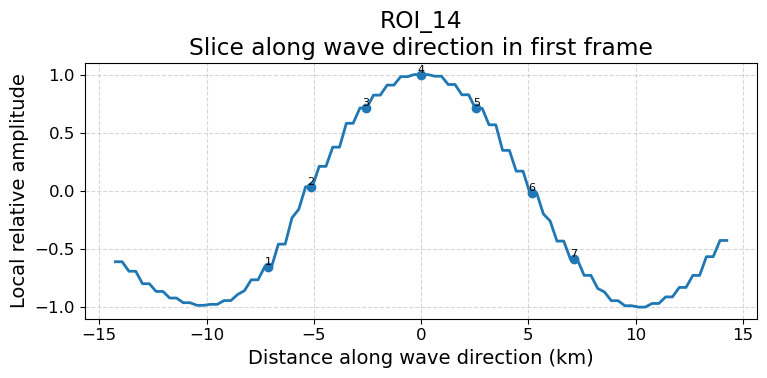

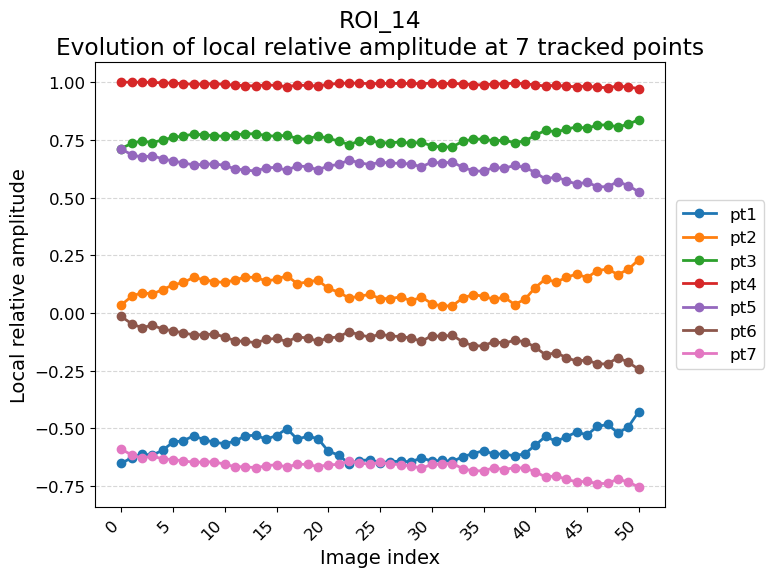

In [10]:
# %%
# Full PNG frame -> ROI -> background removal -> wavelet clusters
# Batch version with crest marker, ridge line, local relative-amplitude panel,
# and weighted wavelength/angle summary values.
#
# MULTI-ROI VERSION:
#   - Define ROI labels in ROI_LABELS, for example:
#         ROI_LABELS = [104, 56]
#   - Builds ROI slices automatically using:
#         ROI ab:
#             x = 20*a : 120 + 20*a
#             y = 16 + 20*b : 136 + 20*b
#   - Runs the same PNG processing pipeline for each ROI
#   - Saves each ROI run into its own subfolder so nothing overwrites
#
# For each PNG in FRAME_DIR, this script:
#   - Loads the PNG frame
#   - Extracts each ROI
#   - Removes a 2D plane + first Fourier mode as background
#   - Applies optional edge taper
#   - Runs juwavelet 2D CWT
#   - Applies band-pass + angle filters before clustering
#   - Identifies clusters on the filtered decomposition
#   - Reconstructs the strongest cluster
#   - Saves an overlay figure with 3 columns:
#         LEFT:   background after removal/tapering
#         MIDDLE: background + cluster reconstruction overlay
#                 + ridge line + 7 tracked points
#         RIGHT:  local relative amplitude
#
# Per ROI:
#   - Uses only the first crest from the first frame
#   - Defines 7 sample points along the wave direction:
#         offsets = [-3, -2, -1, 0, +1, +2, +3]
#   - Samples local relative amplitude at those 7 points for each frame
#   - Saves:
#         crest_relative_amplitude_evolution.npy
#         crest_relative_amplitude_evolution.csv
#
# Weighted wavelength/angle outputs:
#   - wavelength_km:
#         amplitude-weighted mean wavelength inside the selected cluster
#   - wavelength_error_km:
#         amplitude-weighted standard deviation of wavelength inside the selected cluster
#   - angle_deg:
#         amplitude-weighted circular mean angle inside the selected cluster
#   - angle_error_deg:
#         amplitude-weighted circular standard deviation of angle inside the selected cluster
#
# CSV columns:
#   image_index
#   wavelength_km
#   wavelength_error_km
#   angle_deg
#   angle_error_deg
#   pt1, pt2, ..., ptN

%matplotlib inline

from __future__ import annotations
from typing import Tuple, Optional, List

from pathlib import Path
import csv

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import imageio.v3 as iio

from scipy.ndimage import median_filter, maximum_filter, minimum_filter
from scipy import ndimage
from skimage import morphology

from juwavelet import transform, utils


def _silent_print(*args, **kwargs):
    pass


# Silence juwavelet internal print messages
utils.print = _silent_print


# --------------------------
# User params
# --------------------------

# Folder with input PNG frames
FRAME_DIR = out_dir / "awe_radiance_200km_box_interpolated_frames_cropped"

#ROI_LABELS = [104, 56]  # 56 works better
ROI_LABELS = [14]
# ROI definition, same as the TIFF scripts
IMG_NX = 320
IMG_NY = 256

ROI_WIDTH = 120
ROI_HEIGHT = 120
ROI_X_STEP = 20
ROI_Y_STEP = 20
ROI_Y0 = 16

A_MIN, A_MAX = 0, 10
B_MIN, B_MAX = 0, 6

# Optional explicit output folder for overlays
# If None, a subfolder "overlays_crests_phase" is created inside FRAME_DIR
OVERLAY_DIR: Optional[str] = None

# Preprocessing / background
REMOVE_TREND = True
STANDARDIZE = True
GAUSS_BLUR_SIGMA = 0

# Edge taper on remaining field before CWT
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10

# Despike options
# Kept in the pipeline, but disabled here
APPLY_DESPIKE = False
DESPIKE_SIZE = 5
DESPIKE_K = 2.0

# Wavelet params
S0 = 16
DJ = 1 / 12
JS = 12
JT = 36
ASPECT = 1

# Pixel spacing in km/pixel
DX = 0.625
DY = 0.625

# Cluster identification parameters
CLUSTER_MIN_AMP = 0.25
CLUSTER_THR = 0.1

ENABLE_BANDPASS = True
BANDPASS_LMIN_KM = 16.0
BANDPASS_LMAX_KM = 32.0

ENABLE_ANGLE_FILTER = True
ANGLE_MIN_DEG = 60.0
ANGLE_MAX_DEG = 90.0

# Cluster plotting controls
MAX_CLUSTERS = 1

# Crest detection parameters
CREST_NEIGHBORHOOD = 7
CREST_MIN_RELAMP = 0.2
CRESTS_PER_CLUSTER = 1

# Number of tracked sample points
N_SAMPLE_POINTS = 7

# Plot controls
SHOW_FIGS = False
SAVE_OVERLAY = True

# Verbosity
VERBOSE = False


# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 14,
    "font.size": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": [12, 8],
})


def log(msg: str) -> None:
    if VERBOSE:
        print(msg)


# --------------------------
# ROI helpers
# Same as TIFF scripts
# --------------------------
def parse_roi_label(label: int | str) -> Tuple[int, int]:
    """
    Parse ROI label into (a, b).

    Convention:
        last digit  -> b
        remaining   -> a

    Examples:
        104 -> a=10, b=4
        56  -> a=5,  b=6
    """
    s = str(label).strip()

    if not s.isdigit():
        raise ValueError(f"ROI label must be numeric, got: {label}")

    if len(s) < 2:
        raise ValueError(f"ROI label must have at least 2 digits, got: {label}")

    a = int(s[:-1])
    b = int(s[-1])

    return a, b


def roi_label_to_slices(label: int | str) -> Tuple[str, slice, slice]:
    """
    Convert ROI label into name, x_slice, and y_slice.

    ROI definition:
        x = 20*a : 120 + 20*a
        y = 16 + 20*b : 136 + 20*b
    """
    a, b = parse_roi_label(label)

    if not (A_MIN <= a <= A_MAX):
        raise ValueError(f"ROI label {label}: a={a} outside allowed range {A_MIN}..{A_MAX}")

    if not (B_MIN <= b <= B_MAX):
        raise ValueError(f"ROI label {label}: b={b} outside allowed range {B_MIN}..{B_MAX}")

    x0 = ROI_X_STEP * a
    x1 = ROI_WIDTH + ROI_X_STEP * a

    y0 = ROI_Y0 + ROI_Y_STEP * b
    y1 = ROI_Y0 + ROI_HEIGHT + ROI_Y_STEP * b

    if x0 < 0 or x1 > IMG_NX or y0 < 0 or y1 > IMG_NY:
        raise ValueError(
            f"ROI label {label} gives out-of-bounds ROI: "
            f"x={x0}:{x1}, y={y0}:{y1}, image={IMG_NX}x{IMG_NY}"
        )

    name = f"ROI_{label}"

    return name, slice(x0, x1), slice(y0, y1)


def build_roi_sets_from_labels(labels: List[int | str]) -> List[Tuple[str, slice, slice]]:
    """Build ROI list from ROI_LABELS."""
    return [roi_label_to_slices(label) for label in labels]


# --------------------------
# Image helpers
# --------------------------
def load_image(path: str) -> np.ndarray:
    """
    Load single-frame 2D image as float32.

    If the PNG is RGB/RGBA, it is converted to grayscale by averaging channels.
    """
    img = iio.imread(path)

    if img.ndim == 3:
        img = np.mean(img, axis=-1)

    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D image; got shape {img.shape}")

    Z = np.asarray(img, dtype=np.float32)

    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)

    return Z


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """Fit a 2D plane ax + by + c to Z and return the plane."""
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]

    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)

    plane = coeff[0] * xx + coeff[1] * yy + coeff[2]

    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Keep only first Fourier components in x and y.

    Kept components:
        kx = ±1, ky = 0
        ky = ±1, kx = 0

    Returns:
        background_from_fft, residual
    """
    ny, nx = Z.shape

    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg

    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z

    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z

    return gaussian_filter(Z, sigma=float(sigma))


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "nan"

    v = float(v)

    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(Z: np.ndarray, size: int = 3, k: float = 5.0) -> np.ndarray:
    """
    Replace pixels that deviate too much from a local median.

    This function is available, but APPLY_DESPIKE=False by default.
    """
    Z = np.asarray(Z, float)

    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad

    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]

    return Z_clean


# --------------------------
# Edge taper
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """
    1D Hanning-like edge window.

    The window is near 0 at the edges and ramps to 1 over edge pixels.
    """
    w = np.ones(n, dtype=float)

    if edge <= 0:
        return w

    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))

    w[:edge] = ramp
    w[-edge:] = ramp[::-1]

    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """Apply separable 2D Hanning-like taper near ROI boundaries."""
    ny, nx = Z.shape

    if edge <= 0:
        return Z

    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)

    W = np.outer(wy, wx)

    return Z * W


# --------------------------
# Wavelength and angle helpers
# --------------------------
def compute_lambda_theta_fields(cwt: dict) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute effective wavelength and angle for all scale/theta cells.

    Effective wavelength:
        1/lambda^2 = 1/lambda_x^2 + 1/lambda_y^2

    Angle:
        theta = atan2(ky, kx), wrapped to [0, 180)
    """
    lamx = np.asarray(cwt["wavelength_x"], float)
    lamy = np.asarray(cwt["wavelength_y"], float)

    with np.errstate(divide="ignore", invalid="ignore"):
        inv_lamx2 = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / lamx**2, 0.0)
        inv_lamy2 = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / lamy**2, 0.0)

        inv2 = inv_lamx2 + inv_lamy2
        lam_eff = np.where(inv2 > 0, 1.0 / np.sqrt(inv2), np.inf)

        kx = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / lamx, 0.0)
        ky = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / lamy, 0.0)

        theta_deg = np.degrees(np.arctan2(ky, kx))
        theta_deg = np.mod(theta_deg, 180.0)

    return lam_eff, theta_deg


def weighted_mean_std(values: np.ndarray, weights: np.ndarray) -> Tuple[float, float]:
    """Amplitude-weighted mean and standard deviation."""
    values = np.asarray(values, float)
    weights = np.asarray(weights, float)

    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)

    if np.sum(mask) == 0:
        return np.nan, np.nan

    v = values[mask]
    w = weights[mask]

    wsum = np.sum(w)

    if wsum <= 0:
        return np.nan, np.nan

    mean = np.sum(w * v) / wsum
    var = np.sum(w * (v - mean) ** 2) / wsum
    std = np.sqrt(var)

    return float(mean), float(std)


def weighted_circular_mean_std_deg(
    theta_deg_values: np.ndarray,
    weights: np.ndarray,
) -> Tuple[float, float]:
    """
    Amplitude-weighted circular mean and circular standard deviation.

    Uses 180-degree symmetry:
        0 deg and 180 deg are treated as equivalent.
    """
    theta = np.asarray(theta_deg_values, float)
    weights = np.asarray(weights, float)

    mask = np.isfinite(theta) & np.isfinite(weights) & (weights > 0)

    if np.sum(mask) == 0:
        return np.nan, np.nan

    theta = theta[mask]
    w = weights[mask]

    wsum = np.sum(w)

    if wsum <= 0:
        return np.nan, np.nan

    # Double the angle because wave-vector orientation has 180-degree symmetry.
    ang = np.deg2rad(2.0 * theta)

    mean_cos = np.sum(w * np.cos(ang)) / wsum
    mean_sin = np.sum(w * np.sin(ang)) / wsum

    mean_angle = 0.5 * np.rad2deg(np.arctan2(mean_sin, mean_cos))
    mean_angle = np.mod(mean_angle, 180.0)

    R = np.sqrt(mean_cos**2 + mean_sin**2)

    if not np.isfinite(R) or R <= 0:
        std_angle = np.nan
    else:
        R = min(R, 1.0)
        std_angle = np.rad2deg(np.sqrt(-2.0 * np.log(R))) / 2.0

    return float(mean_angle), float(std_angle)


def compute_cluster_weighted_lambda_angle(
    cwt: dict,
    iwave: np.ndarray,
    kcl: int,
) -> Tuple[float, float, float, float, int]:
    """
    Compute weighted wavelength and weighted angle for the selected cluster.

    Outputs:
        wavelength_mean_km
        wavelength_error_km
        angle_mean_deg
        angle_error_deg
        n_cluster_points

    Weights come from wavelet amplitude summed over pixels for each
    scale/angle cell inside the selected cluster.
    """
    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)
    decomposition = np.asarray(cwt["decomposition"])

    cluster_mask = iwave == kcl
    cluster_st = np.any(cluster_mask, axis=(2, 3))
    n_points = int(np.sum(cluster_st))

    if n_points == 0:
        return np.nan, np.nan, np.nan, np.nan, 0

    # Weight each scale/angle point by total cluster amplitude over x/y.
    amp_st = np.sum(np.abs(decomposition) * cluster_mask, axis=(2, 3))

    lam_vals = lam_eff[cluster_st]
    theta_vals = theta_deg[cluster_st]
    weights = amp_st[cluster_st]

    lam_mean, lam_err = weighted_mean_std(lam_vals, weights)
    theta_mean, theta_err = weighted_circular_mean_std_deg(theta_vals, weights)

    return lam_mean, lam_err, theta_mean, theta_err, n_points


# --------------------------
# Crest detection
# --------------------------
def find_top_crests(
    Z: np.ndarray,
    num: int = 1,
    neighborhood: int = 7,
    min_rel_amp: float = 0.2,
) -> List[Tuple[int, int, float]]:
    """
    Find up to num strongest positive local crests.

    Returns:
        list of (iy, ix, value)
    """
    Z = np.asarray(Z, float)

    if Z.size == 0:
        return []

    max_val = np.nanmax(Z)

    if not np.isfinite(max_val) or max_val <= 0:
        return []

    neighborhood = max(int(neighborhood), 1)

    local_max = maximum_filter(Z, size=neighborhood, mode="nearest")
    mask = (Z == local_max) & (Z > 0) & (Z >= min_rel_amp * max_val)

    ys, xs = np.where(mask)

    if ys.size == 0:
        iy, ix = np.unravel_index(np.nanargmax(Z), Z.shape)
        return [(int(iy), int(ix), float(Z[iy, ix]))][:num]

    vals = Z[ys, xs]
    order = np.argsort(vals)[::-1]

    crests: List[Tuple[int, int, float]] = []

    for idx in order[:num]:
        crests.append((int(ys[idx]), int(xs[idx]), float(vals[idx])))

    return crests


# --------------------------
# Ridge line
# --------------------------
def compute_ridge_mask(Z: np.ndarray, level_frac: float = 0.6) -> np.ndarray:
    """
    Compute a 1-pixel-wide skeleton ridge for the dominant bright band.
    """
    Z = np.asarray(Z, float)

    if Z.size == 0:
        return np.zeros_like(Z, dtype=bool)

    max_val = np.nanmax(Z)

    if not np.isfinite(max_val) or max_val <= 0:
        return np.zeros_like(Z, dtype=bool)

    level = level_frac * max_val
    mask = Z >= level

    if not np.any(mask):
        return np.zeros_like(Z, dtype=bool)

    labels, num = ndimage.label(mask)

    if num == 0:
        return np.zeros_like(Z, dtype=bool)

    iy_max, ix_max = np.unravel_index(np.nanargmax(Z), Z.shape)
    label_peak = labels[iy_max, ix_max]

    if label_peak == 0:
        return np.zeros_like(Z, dtype=bool)

    peak_comp = labels == label_peak
    ridge = morphology.skeletonize(peak_comp)

    return ridge


# --------------------------
# Single-frame pipeline
# --------------------------
def run_pipeline_for_file(
    img_path: Path,
    overlay_dir: Path,
    x_slice: Optional[slice],
    y_slice: Optional[slice],
    show_figs: bool = False,
    save_overlay: bool = True,
    crest_iy: Optional[np.ndarray] = None,
    crest_ix: Optional[np.ndarray] = None,
    init_crests_from_this_file: bool = False,
) -> Tuple[
    Optional[np.ndarray],
    Optional[np.ndarray],
    Optional[np.ndarray],
    Optional[dict],
    float,
    float,
    float,
    float,
]:
    """
    Run the full processing pipeline on one PNG frame for one ROI.

    Returns:
        vals_on_crests
        crest_iy
        crest_ix
        first_frame_info
        wavelength_km
        angle_deg
        wavelength_error_km
        angle_error_deg
    """
    log(f"\n=== Processing {img_path.name} ===")

    full = load_image(str(img_path))

    ny_full, nx_full = full.shape

    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)

    first_frame_info: Optional[dict] = None

    # Optional full-frame preview with ROI box
    if show_figs:
        vals_full = full.ravel().astype(float)
        p2, p98 = np.nanpercentile(vals_full, [2, 98])
        vmin_prev, vmax_prev = p2, p98

        y_full_flip = y_full[::-1]

        fig_prev, ax_prev = plt.subplots()

        im_prev = ax_prev.pcolormesh(
            x_full,
            y_full_flip,
            full,
            shading="auto",
            cmap="gray",
            vmin=vmin_prev,
            vmax=vmax_prev,
        )

        cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
        cb_prev.set_label("Intensity (a.u.)")

        ax_prev.set_xlabel("x (pixels)")
        ax_prev.set_ylabel("y (pixels)")
        ax_prev.set_title(f"{img_path.name}\nFull frame, 2 to 98 percentile stretch")
        ax_prev.set_aspect("equal", adjustable="box")

        ysl_full = y_slice if y_slice is not None else slice(0, ny_full)
        xsl_full = x_slice if x_slice is not None else slice(0, nx_full)

        x0 = 0 if xsl_full.start is None else xsl_full.start
        x1 = nx_full if xsl_full.stop is None else xsl_full.stop
        y0 = 0 if ysl_full.start is None else ysl_full.start
        y1 = ny_full if ysl_full.stop is None else ysl_full.stop

        y0_disp = ny_full - y1
        y1_disp = ny_full - y0

        rect = patches.Rectangle(
            (x0, y0_disp),
            x1 - x0,
            y1_disp - y0_disp,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )

        ax_prev.add_patch(rect)

        plt.tight_layout()
        plt.show()

    # Extract ROI
    ysl = y_slice if y_slice is not None else slice(None, None)
    xsl = x_slice if x_slice is not None else slice(None, None)

    raw = full[ysl, xsl].astype(float)

    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]

    log(f"[ROI] shape: {raw.shape}")

    proc0 = raw.copy()

    # Background separation: 2D plane + first Fourier background
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # Edge taper
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Optional despike
    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered,
            size=DESPIKE_SIZE,
            k=DESPIKE_K,
        )
    else:
        remaining_tapered_clean = remaining_tapered

    # Centered versions for diagnostic plotting
    med = np.nanmedian(proc0)

    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    stacked = np.concatenate([
        orig_c.ravel(),
        bg_c.ravel(),
        rem_c.ravel(),
        rem_tapered_c.ravel(),
    ])

    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))

    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0

    vmin = -vmax

    # Optional 4-panel background diagnostic
    if show_figs:
        fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
        axes_bg_flat = axs_bg.flatten()

        imgs_bg = [
            (orig_c, "Original, median-subtracted"),
            (bg_c, "Background: plane + first Fourier"),
            (rem_c, "Remaining = original - background"),
            (rem_tapered_c, "Remaining after edge taper"),
        ]

        im_bg = None

        for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
            im_bg = ax.pcolormesh(
                x1d,
                y1d,
                Z,
                shading="auto",
                cmap="RdBu_r",
                vmin=vmin,
                vmax=vmax,
            )

            ax.set_title(title)
            ax.set_xlabel("x (pixels)")
            ax.set_ylabel("y (pixels)")
            ax.set_aspect("equal")

        cbar_bg = fig_bg.colorbar(
            im_bg,
            ax=axs_bg,
            orientation="vertical",
            fraction=0.04,
            pad=0.02,
        )

        cbar_bg.set_label("Intensity (a.u.)")
        plt.show()

    # Preprocess for CWT
    proc = remaining_tapered_clean.copy()

    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc

        s_proc = np.std(proc)

        if s_proc > 0:
            proc = proc / s_proc

    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy,
        dx=DX,
        dy=DY,
        s0=S0,
        dj=DJ,
        js=JS,
        jt=JT,
        aspect=ASPECT,
    )

    # Apply wavelength and angle filters before clustering
    decomposition = cwt["decomposition"]

    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)

    mask_keep = np.ones_like(lam_eff, dtype=bool)

    if ENABLE_BANDPASS:
        mask_keep &= (
            np.isfinite(lam_eff)
            & (lam_eff >= BANDPASS_LMIN_KM)
            & (lam_eff <= BANDPASS_LMAX_KM)
        )

    if ENABLE_ANGLE_FILTER:
        mask_keep &= (
            np.isfinite(theta_deg)
            & (theta_deg >= ANGLE_MIN_DEG)
            & (theta_deg <= ANGLE_MAX_DEG)
        )

    mask4 = mask_keep[:, :, None, None].astype(decomposition.dtype)
    decomposition *= mask4

    # Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(
        cwt,
        min_amp=CLUSTER_MIN_AMP,
        thr=CLUSTER_THR,
    )

    orig_decomp = decomposition.copy()

    # Background for overlay plots
    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)

    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))

    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0

    bg_vmin = -bg_vmax

    n_clusters = len(amps) if amps is not None else 0
    log(f"[Clusters] n_clusters after filters = {n_clusters}")

    crest_iy_out = crest_iy
    crest_ix_out = crest_ix

    vals_on_crests: Optional[np.ndarray] = None

    wavelength_km_out = np.nan
    wavelength_error_km_out = np.nan
    angle_deg_out = np.nan
    angle_error_deg_out = np.nan

    # No cluster case
    if n_clusters == 0:
        fig_empty, ax = plt.subplots(figsize=(6, 4))

        ax.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_title("No clusters after filters")

        fig_empty.tight_layout()

        if save_overlay:
            overlay_dir.mkdir(parents=True, exist_ok=True)
            out_path = overlay_dir / f"{img_path.stem}_overlay_clusters_crests_phase.png"
            fig_empty.savefig(out_path, dpi=200)

        if show_figs:
            plt.show(fig_empty)
        else:
            plt.close(fig_empty)

        return (
            None,
            crest_iy_out,
            crest_ix_out,
            None,
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )

    # Sort clusters by amplitude and show strongest ones
    order = np.argsort(amps)[::-1]
    n_show = min(n_clusters, MAX_CLUSTERS)

    fig, axes = plt.subplots(
        n_show,
        3,
        figsize=(15, 4 * n_show),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_2d(axes)

    for j in range(n_show):
        kcl = int(order[j])

        ax_bg = axes[j, 0]
        ax_ov = axes[j, 1]
        ax_ph = axes[j, 2]

        # LEFT: background field
        ax_bg.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )

        ax_bg.set_title("Background after removal/taper")
        ax_bg.set_aspect("equal", adjustable="box")
        ax_bg.set_xlabel("x (pixels)")
        ax_bg.set_ylabel("y (pixels)")

        # MIDDLE: cluster reconstruction overlay
        decomposition[:] = orig_decomp
        decomposition[iwave != kcl] = 0

        rec = transform.reconstruct2d(cwt)
        rec_centered = rec.T - np.median(rec)

        ny_img, nx_img = rec_centered.shape

        ax_ov.pcolormesh(
            x1d,
            y1d,
            bg_tapered_centered,
            shading="auto",
            cmap="gray",
            vmin=bg_vmin,
            vmax=bg_vmax,
        )

        ax_ov.pcolormesh(
            x1d,
            y1d,
            rec_centered,
            shading="auto",
            cmap="RdBu_r",
            vmin=-0.6,
            vmax=0.6,
            alpha=0.6,
        )

        # Ridge line
        ridge_mask = compute_ridge_mask(rec_centered, level_frac=0.6)

        if np.any(ridge_mask):
            ys_ridge, xs_ridge = np.where(ridge_mask)
            order_r = np.argsort(xs_ridge)

            xs_sorted = xs_ridge[order_r].astype(float)
            ys_sorted = ys_ridge[order_r].astype(float)

            x_disp_r = xs_sorted
            y_disp_r = ny_img - 1 - ys_sorted

            ax_ov.plot(x_disp_r, y_disp_r, linewidth=1.5, color="yellow")

        # Weighted wavelength and angle for this cluster
        wavelength_km, wavelength_error_km, angle_deg, angle_error_deg, n_cluster_points = (
            compute_cluster_weighted_lambda_angle(cwt, iwave, kcl)
        )

        if j == 0:
            wavelength_km_out = float(wavelength_km)
            wavelength_error_km_out = float(wavelength_error_km)
            angle_deg_out = float(angle_deg)
            angle_error_deg_out = float(angle_error_deg)

        ax_ov.set_title(
            f"Cluster {j + 1} (id={kcl}, N={n_cluster_points})\n"
            + rf"$\lambda_w$={_fmt(wavelength_km)}±{_fmt(wavelength_error_km)} km, "
            + rf"$\theta_w$={angle_deg:.1f}±{angle_error_deg:.1f}°"
        )

        ax_ov.set_aspect("equal", adjustable="box")
        ax_ov.set_xlabel("x (pixels)")
        ax_ov.set_ylabel("y (pixels)")

        # RIGHT: local relative amplitude
        if np.isfinite(wavelength_km) and wavelength_km > 0:
            radius_km = wavelength_km / 2.0
            radius_pix = max(int(np.round(radius_km / DX)), 1)
        else:
            radius_pix = 1

        win_size = 2 * radius_pix + 1

        local_max = maximum_filter(rec_centered, size=win_size, mode="nearest")
        local_min = minimum_filter(rec_centered, size=win_size, mode="nearest")

        denom = local_max - local_min
        denom_safe = np.where(denom != 0, denom, np.nan)

        rel_amp = -1.0 + 2.0 * (rec_centered - local_min) / denom_safe
        rel_amp = np.where(np.isfinite(rel_amp), rel_amp, 0.0)
        rel_amp = np.clip(rel_amp, -1.0, 1.0)

        mask_cluster_xy = np.any(iwave == kcl, axis=(0, 1))
        mask_cluster_img = mask_cluster_xy.T

        rel_amp_cluster = np.where(mask_cluster_img, rel_amp, np.nan)

        im_rel = ax_ph.pcolormesh(
            x1d,
            y1d,
            rel_amp_cluster,
            shading="auto",
            cmap="RdBu_r",
            vmin=-1.0,
            vmax=1.0,
        )

        ax_ph.set_title(r"Local relative amplitude, radius $\lambda_w/2$")
        ax_ph.set_aspect("equal", adjustable="box")
        ax_ph.set_xlabel("x (pixels)")
        ax_ph.set_ylabel("y (pixels)")

        cbar_ph = fig.colorbar(im_rel, ax=ax_ph, fraction=0.046, pad=0.04)
        cbar_ph.set_label("Relative amplitude")

        # First crest and 7 sample points
        crests = find_top_crests(
            rec_centered,
            num=CRESTS_PER_CLUSTER,
            neighborhood=CREST_NEIGHBORHOOD,
            min_rel_amp=CREST_MIN_RELAMP,
        )

        if j == 0:
            if init_crests_from_this_file and crest_iy_out is None and crest_ix_out is None:
                if len(crests) > 0:
                    crest0_iy, crest0_ix, _ = crests[0]

                    theta_rad = np.deg2rad(angle_deg)
                    ux = np.cos(theta_rad)
                    uy = np.sin(theta_rad)

                    step_pix = max(radius_pix // 4, 1)

                    offsets = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float)

                    if offsets.size != N_SAMPLE_POINTS:
                        offsets = np.linspace(-3, 3, N_SAMPLE_POINTS)

                    sample_ix = crest0_ix + np.round(step_pix * offsets * ux).astype(int)
                    sample_iy = crest0_iy + np.round(step_pix * offsets * uy).astype(int)

                    pixel_shifts = np.zeros(N_SAMPLE_POINTS, dtype=float)

                    for idx_pt, pix_shift in enumerate(pixel_shifts):
                        dx = int(np.round(pix_shift * ux))
                        dy = int(np.round(pix_shift * uy))

                        sample_ix[idx_pt] += dx
                        sample_iy[idx_pt] += dy

                    sample_ix = np.clip(sample_ix, 0, nx_img - 1)
                    sample_iy = np.clip(sample_iy, 0, ny_img - 1)

                    crest_ix_out = sample_ix
                    crest_iy_out = sample_iy

                    for n_pt in range(N_SAMPLE_POINTS):
                        x_disp = float(crest_ix_out[n_pt])
                        y_disp = float(ny_img - 1 - crest_iy_out[n_pt])

                        ax_ov.plot(
                            x_disp,
                            y_disp,
                            marker="o",
                            markersize=4,
                            markeredgecolor="magenta",
                            markerfacecolor="magenta",
                            markeredgewidth=0.8,
                        )

                        ax_ov.text(
                            x_disp + 1.0,
                            y_disp + 1.0,
                            f"{n_pt + 1}",
                            color="cyan",
                            fontsize=8,
                            weight="bold",
                        )

            # Save first-frame info for diagnostic 1D slice plot
            if init_crests_from_this_file and crest_iy_out is not None and crest_ix_out is not None:
                first_frame_info = {
                    "rel_amp": rel_amp.copy(),
                    "crest_iy": crest_iy_out.copy(),
                    "crest_ix": crest_ix_out.copy(),
                }

            # Sample relative amplitude at the same 7 points in every frame
            if crest_iy_out is not None and crest_ix_out is not None:
                if crest_iy_out.max() < ny_img and crest_ix_out.max() < nx_img:
                    vals_on_crests = rel_amp[crest_iy_out, crest_ix_out]
                else:
                    vals_on_crests = None

    fig.suptitle(f"{img_path.name}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if save_overlay:
        overlay_dir.mkdir(parents=True, exist_ok=True)
        out_path = overlay_dir / f"{img_path.stem}_overlay_clusters_crests_phase.png"
        fig.savefig(out_path, dpi=200)

    if show_figs:
        plt.show(fig)
    else:
        plt.close(fig)

    return (
        vals_on_crests,
        crest_iy_out,
        crest_ix_out,
        first_frame_info,
        float(wavelength_km_out),
        float(angle_deg_out),
        float(wavelength_error_km_out),
        float(angle_error_deg_out),
    )


# --------------------------
# Batch driver for one ROI
# --------------------------
def run_batch_one_roi(roi_name: str, x_slice: slice, y_slice: slice) -> None:
    frame_dir = Path(FRAME_DIR)

    if OVERLAY_DIR is not None:
        base_overlay_dir = Path(OVERLAY_DIR)
    else:
        base_overlay_dir = frame_dir / "overlays_crests_phase"

    overlay_dir = base_overlay_dir / roi_name

    files = sorted(list(frame_dir.glob("*.png")))

    if not files:
        print(f"No PNG image files found in {frame_dir}")
        return

    print(f"\nROI: {roi_name}")
    print(f"  X_SLICE: {x_slice}")
    print(f"  Y_SLICE: {y_slice}")
    print(f"  Found {len(files)} PNG image files in {frame_dir}")
    print(f"  Overlay output directory: {overlay_dir}")

    crest_iy = None
    crest_ix = None

    crest_value_series: List[np.ndarray] = []
    frame_indices: List[int] = []

    wavelength_series_km: List[float] = []
    wavelength_error_series_km: List[float] = []

    angle_series_deg: List[float] = []
    angle_error_series_deg: List[float] = []

    first_frame_info: Optional[dict] = None

    for i, img_path in enumerate(files):
        (
            vals_on_crests,
            crest_iy,
            crest_ix,
            first_info,
            wavelength_km,
            angle_deg,
            wavelength_error_km,
            angle_error_deg,
        ) = run_pipeline_for_file(
            img_path=img_path,
            overlay_dir=overlay_dir,
            x_slice=x_slice,
            y_slice=y_slice,
            show_figs=SHOW_FIGS,
            save_overlay=SAVE_OVERLAY,
            crest_iy=crest_iy,
            crest_ix=crest_ix,
            init_crests_from_this_file=(i == 0),
        )

        if first_frame_info is None and first_info is not None:
            first_frame_info = first_info

        if vals_on_crests is not None:
            crest_value_series.append(vals_on_crests)
            frame_indices.append(i)

            wavelength_series_km.append(float(wavelength_km))
            wavelength_error_series_km.append(float(wavelength_error_km))

            angle_series_deg.append(float(angle_deg))
            angle_error_series_deg.append(float(angle_error_deg))

    if not crest_value_series:
        print("  No amplitude data collected for this ROI.")
        return

    val_arr = np.vstack(crest_value_series)

    n_files_used, n_points = val_arr.shape
    frames = np.array(frame_indices, dtype=int)

    overlay_dir.mkdir(parents=True, exist_ok=True)

    # Save NPY
    npy_path = overlay_dir / "crest_relative_amplitude_evolution.npy"
    np.save(npy_path, val_arr)

    # Save CSV
    csv_path = overlay_dir / "crest_relative_amplitude_evolution.csv"

    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)

        header = [
            "image_index",
            "wavelength_km",
            "wavelength_error_km",
            "angle_deg",
            "angle_error_deg",
        ] + [f"pt{p + 1}" for p in range(n_points)]

        writer.writerow(header)

        for irow in range(n_files_used):
            row = [
                int(frames[irow]),
                float(wavelength_series_km[irow]),
                float(wavelength_error_series_km[irow]),
                float(angle_series_deg[irow]),
                float(angle_error_series_deg[irow]),
            ] + [float(x) for x in val_arr[irow, :]]

            writer.writerow(row)

    print(f"  Saved: {npy_path}")
    print(f"  Saved: {csv_path}")

    # Show first overlay crop
    try:
        first_overlay_path = overlay_dir / f"{files[0].stem}_overlay_clusters_crests_phase.png"

        if first_overlay_path.exists():
            img0 = plt.imread(first_overlay_path)
            h, w = img0.shape[:2]

            x0c, x1c = 1100, 1900
            x0c = max(0, min(x0c, w - 1))
            x1c = max(x0c + 1, min(x1c, w))

            img0_crop = img0[:, x0c:x1c, :]

            fig0, ax0 = plt.subplots(figsize=(6, 6))
            ax0.imshow(img0_crop)
            ax0.set_axis_off()
            ax0.set_title(f"{roi_name}\nFirst overlay crop: {files[0].name}")
            plt.tight_layout()
            plt.show()

    except Exception as e:
        if VERBOSE:
            print(f"[Warning] Could not display first overlay image: {e}")

    # Diagnostic 1D slice along wave direction in first frame
    if first_frame_info is not None:
        rel0 = np.asarray(first_frame_info["rel_amp"], float)
        samp_iy = np.asarray(first_frame_info["crest_iy"], float)
        samp_ix = np.asarray(first_frame_info["crest_ix"], float)

        ny0, nx0 = rel0.shape

        x0_mean = samp_ix.mean()
        y0_mean = samp_iy.mean()

        vx = samp_ix[-1] - samp_ix[0]
        vy = samp_iy[-1] - samp_iy[0]

        norm = np.hypot(vx, vy)

        if norm == 0:
            vx, vy, norm = 1.0, 0.0, 1.0

        ux = vx / norm
        uy = vy / norm

        s_pts = (samp_ix - x0_mean) * ux + (samp_iy - y0_mean) * uy

        center_idx = N_SAMPLE_POINTS // 2
        s0 = s_pts[center_idx] if 0 <= center_idx < len(s_pts) else s_pts.mean()

        dist_pts_km = (s_pts - s0) * DX

        margin_pix = norm * 0.5
        s_min = s_pts.min() - margin_pix
        s_max = s_pts.max() + margin_pix

        n_line = max(int((s_max - s_min) * 2), 50)
        s_line = np.linspace(s_min, s_max, n_line)

        x_line = x0_mean + s_line * ux
        y_line = y0_mean + s_line * uy

        x_idx = np.clip(np.round(x_line).astype(int), 0, nx0 - 1)
        y_idx = np.clip(np.round(y_line).astype(int), 0, ny0 - 1)

        rel_slice = rel0[y_idx, x_idx]
        dist_line_km = (s_line - s0) * DX

        pt_vals0 = val_arr[0, :]

        fig_slice, ax_slice = plt.subplots(figsize=(8, 4))

        ax_slice.plot(dist_line_km, rel_slice, linewidth=2)
        ax_slice.scatter(dist_pts_km, pt_vals0, zorder=3)

        for n in range(len(dist_pts_km)):
            ax_slice.text(
                dist_pts_km[n],
                pt_vals0[n],
                f"{n + 1}",
                fontsize=8,
                ha="center",
                va="bottom",
            )

        ax_slice.set_xlabel("Distance along wave direction (km)")
        ax_slice.set_ylabel("Local relative amplitude")
        ax_slice.set_title(f"{roi_name}\nSlice along wave direction in first frame")
        ax_slice.grid(True, linestyle="--", alpha=0.5)

        plt.tight_layout()
        plt.show()

    # Evolution plot
    fig, ax = plt.subplots(figsize=(10, 6))

    for p in range(n_points):
        ax.plot(
            frames,
            val_arr[:, p],
            marker="o",
            linewidth=2,
            label=f"pt{p + 1}",
        )

    ax.set_xlabel("Image index")
    ax.set_ylabel("Local relative amplitude")
    ax.set_title(f"{roi_name}\nEvolution of local relative amplitude at 7 tracked points")

    if len(frames) > 0:
        tick_positions = frames[::5]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_positions, rotation=45, ha="right")
    else:
        ax.set_xticks([])
        ax.set_xticklabels([])

    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()


# --------------------------
# Batch driver for all ROI labels
# --------------------------
def run_all_rois() -> None:
    if "ROI_LABELS" not in globals():
        raise NameError(
            "ROI_LABELS is not defined. Please define ROI_LABELS in the previous cell, "
            "for example: ROI_LABELS = [104, 56]"
        )

    roi_sets = build_roi_sets_from_labels(ROI_LABELS)

    print("Using ROIs:")
    for roi_name, xsl, ysl in roi_sets:
        print(f"  {roi_name}: x={xsl.start}:{xsl.stop}, y={ysl.start}:{ysl.stop}")

    for roi_name, xsl, ysl in roi_sets:
        run_batch_one_roi(roi_name, xsl, ysl)


if __name__ == "__main__":
    run_all_rois()

## Animation from png files

In [11]:
# %%
# Make a movie from the saved PNG overlays created by the PNG ROI batch script.
#
# The pasted batch script saves overlay images here:
#   FRAME_DIR/overlays_crests_phase/ROI_<label>/*_overlay_clusters_crests_phase.png
#
# Example:
#   FRAME_DIR/overlays_crests_phase/ROI_104/
#   FRAME_DIR/overlays_crests_phase/ROI_56/
#
# This cell:
#   - Uses ROI_LABELS from the batch script if available
#   - Otherwise automatically finds ROI_* folders
#   - Sorts frames naturally by frame number
#   - Writes one movie per ROI folder
#
# Output:
#   FRAME_DIR/overlays_crests_phase/ROI_104/ROI_104_overlay_clusters_crests_phase.mp4
#
# Requirements:
#   conda install -c conda-forge ffmpeg imageio imageio-ffmpeg
# or
#   pip install imageio imageio-ffmpeg

from __future__ import annotations
from pathlib import Path
import re

import imageio.v2 as imageio


# --------------------------
# Settings
# --------------------------
FPS = 5

# If None, uses Path(FRAME_DIR) / "overlays_crests_phase"
OVERLAY_BASE_DIR: str | Path | None = None

# If None, use ROI_LABELS if available.
# If ROI_LABELS is not available, auto-detect ROI folders.
# Example:
#   ONLY_ROIS = ["ROI_104", "ROI_56"]
ONLY_ROIS: list[str] | None = None

PNG_GLOB = "*_overlay_clusters_crests_phase.png"

# "mp4" or "gif"
OUT_EXT = "mp4"


# --------------------------
# Helpers
# --------------------------
def _natural_key(p: Path):
    """
    Sort using the last integer in the filename.

    This usually matches the frame number, e.g.
        frame_0001_overlay_clusters_crests_phase.png
    """
    nums = re.findall(r"\d+", p.stem)
    n = int(nums[-1]) if nums else -1
    return (n, p.name)


def get_overlay_base_dir() -> Path:
    if "FRAME_DIR" not in globals() and OVERLAY_BASE_DIR is None:
        raise NameError(
            "FRAME_DIR is not defined and OVERLAY_BASE_DIR is None.\n"
            "Either run the batch script first or set OVERLAY_BASE_DIR manually."
        )

    if OVERLAY_BASE_DIR is not None:
        return Path(OVERLAY_BASE_DIR)

    return Path(FRAME_DIR) / "overlays_crests_phase"


def get_roi_names(overlay_base: Path) -> list[str]:
    """
    Determine ROI folder names.

    Priority:
      1. ONLY_ROIS if provided
      2. ROI_LABELS from the pasted batch script
      3. Auto-detect folders containing overlay PNGs
    """
    if ONLY_ROIS is not None:
        return list(ONLY_ROIS)

    if "ROI_LABELS" in globals():
        return [f"ROI_{label}" for label in ROI_LABELS]

    roi_dirs = sorted(
        [
            p for p in overlay_base.iterdir()
            if p.is_dir() and list(p.glob(PNG_GLOB))
        ],
        key=lambda p: p.name,
    )

    return [p.name for p in roi_dirs]


def make_movie_from_pngs(pngs: list[Path], out_path: Path, fps: int) -> None:
    if not pngs:
        raise ValueError("No PNGs provided.")

    out_path.parent.mkdir(parents=True, exist_ok=True)

    if out_path.suffix.lower() == ".gif":
        with imageio.get_writer(out_path, mode="I", duration=1.0 / fps) as writer:
            for p in pngs:
                writer.append_data(imageio.imread(p))
        return

    if out_path.suffix.lower() != ".mp4":
        raise ValueError(f"Unsupported output extension: {out_path.suffix}")

    try:
        with imageio.get_writer(
            out_path,
            fps=fps,
            codec="libx264",
            quality=8,
            macro_block_size=1,
        ) as writer:
            for p in pngs:
                writer.append_data(imageio.imread(p))

    except Exception as e:
        raise RuntimeError(
            "Failed to write MP4. You probably need ffmpeg.\n"
            "Try one of these:\n"
            "  conda install -c conda-forge ffmpeg imageio-ffmpeg\n"
            "  pip install imageio-ffmpeg\n"
            f"Original error: {e}"
        )


# --------------------------
# Main
# --------------------------
overlay_base = get_overlay_base_dir()
roi_names = get_roi_names(overlay_base)

if not roi_names:
    raise FileNotFoundError(
        f"No ROI folders found in:\n  {overlay_base}\n"
        f"Expected folders like ROI_104 with PNGs matching:\n  {PNG_GLOB}"
    )

print("Overlay base:", overlay_base)
print("ROIs:", roi_names)
print("FPS:", FPS)
print("Output extension:", OUT_EXT)

for roi_name in roi_names:
    roi_dir = overlay_base / roi_name

    if not roi_dir.exists():
        print(f"[skip] ROI folder not found: {roi_dir}")
        continue

    pngs = sorted(roi_dir.glob(PNG_GLOB), key=_natural_key)

    if not pngs:
        print(f"[skip] No PNGs found in {roi_dir}")
        print(f"       Pattern: {PNG_GLOB}")
        continue

    out_path = roi_dir / f"{roi_name}_overlay_clusters_crests_phase.{OUT_EXT}"

    print(f"[write] {roi_name}: {len(pngs)} frames -> {out_path}")

    make_movie_from_pngs(
        pngs=pngs,
        out_path=out_path,
        fps=FPS,
    )

print("Done.")

Overlay base: AWE\06326\remap85\awe_radiance_200km_box_interpolated_frames_cropped\overlays_crests_phase
ROIs: ['ROI_14']
FPS: 5
Output extension: mp4
[write] ROI_14: 51 frames -> AWE\06326\remap85\awe_radiance_200km_box_interpolated_frames_cropped\overlays_crests_phase\ROI_14\ROI_14_overlay_clusters_crests_phase.mp4
Done.


## Grid Search

Overlay base: AWE\06326\remap85\awe_radiance_200km_box_interpolated_frames_cropped\overlays_crests_phase
DT between frames = 1.100 s
Initial a0 = 0.333333 deg/frame
Found ROI CSVs:
  ROI_14

Loading CSV from: AWE\06326\remap85\awe_radiance_200km_box_interpolated_frames_cropped\overlays_crests_phase\ROI_14\crest_relative_amplitude_evolution.csv
[ROI_14] Data shape (frames, points): (51, 7)
[ROI_14] Wavelength stats (km): min=21.89, median=22.15, max=22.50
[ROI_14] Wavelength error stats (km): median=4.67, max=4.76
[ROI_14] Angle stats (deg): min=72.94, median=73.15, max=73.33
[ROI_14] Angle error stats (deg): median=7.37, max=7.46

[ROI_14] Best a = 0.108333 deg/frame
[ROI_14] Initial a0 = 0.333333 deg/frame
[ROI_14] Factor = 0.325
[ROI_14] SSE_min = 0.4073


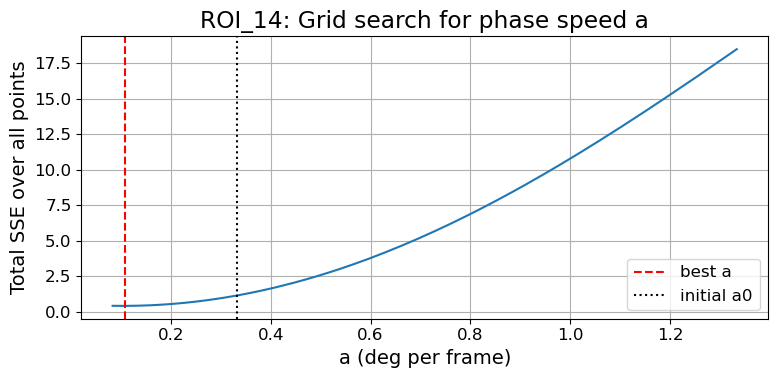


[ROI_14] Per-point best phases:
  pt1: b = 232.0 deg, SSE=0.1430
  pt2: b = 273.5 deg, SSE=0.1364
  pt3: b = 317.0 deg, SSE=0.0327
  pt4: b = 5.5 deg, SSE=0.0015
  pt5: b = 48.5 deg, SSE=0.0323
  pt6: b = 94.5 deg, SSE=0.0419
  pt7: b = 129.5 deg, SSE=0.0195


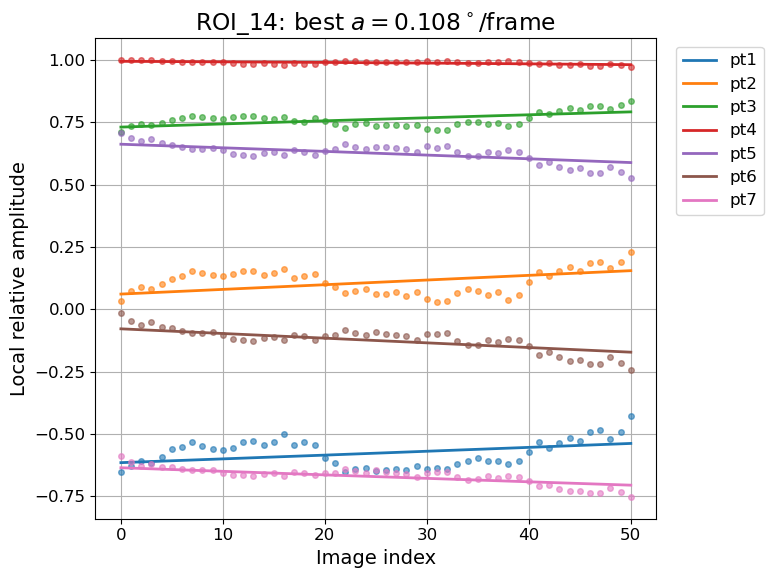


[ROI_14] Automatic direction = -1
[ROI_14] Phase slope across points = 43.79 deg/point
[ROI_14] Phase shift per frame = -0.108333 deg/frame


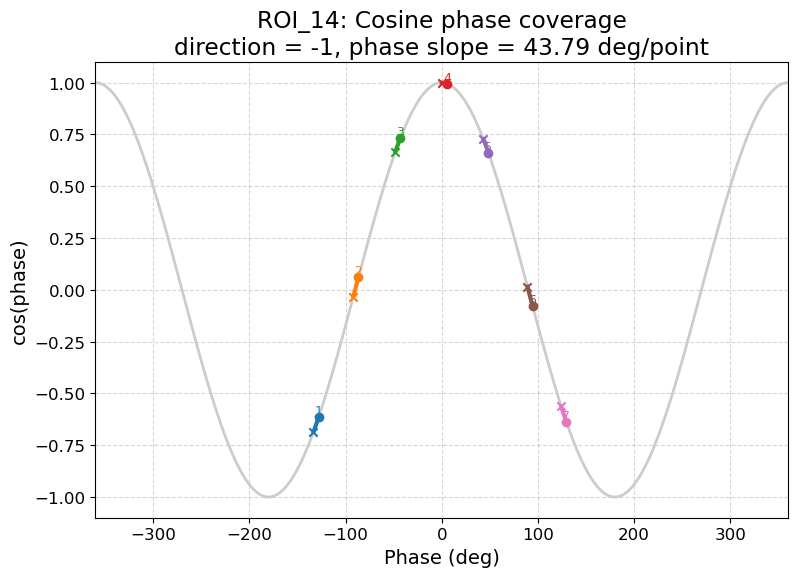


[ROI_14] Overall phase speed:
  avg wavelength = 22.18 ± 4.68 km
  avg angle = 73.13 ± 7.35 deg
  best a = 0.108333 deg/frame
  direction = -1
  phase slope = 43.79 deg/point
  phase speed = -6.07 ± 1.28 m/s

[ROI_14] Running phase speed:
WINDOW=30, STEP=5, total windows=5

First window only plots
Rows 0..29, frames 0..29
Best a = 0.0958 deg/frame
Avg λ = 22.25 ± 4.69 km
Avg angle = 73.15 ± 7.34 deg
Direction = -1
Phase slope = 1.62 deg/point
Signed phase speed = -5.39 ± 1.14 m/s


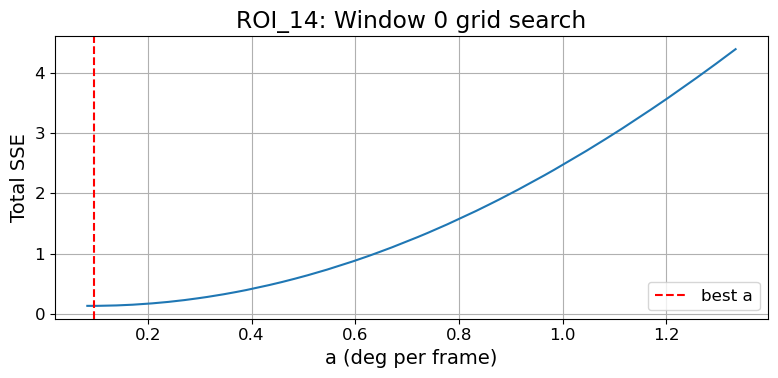

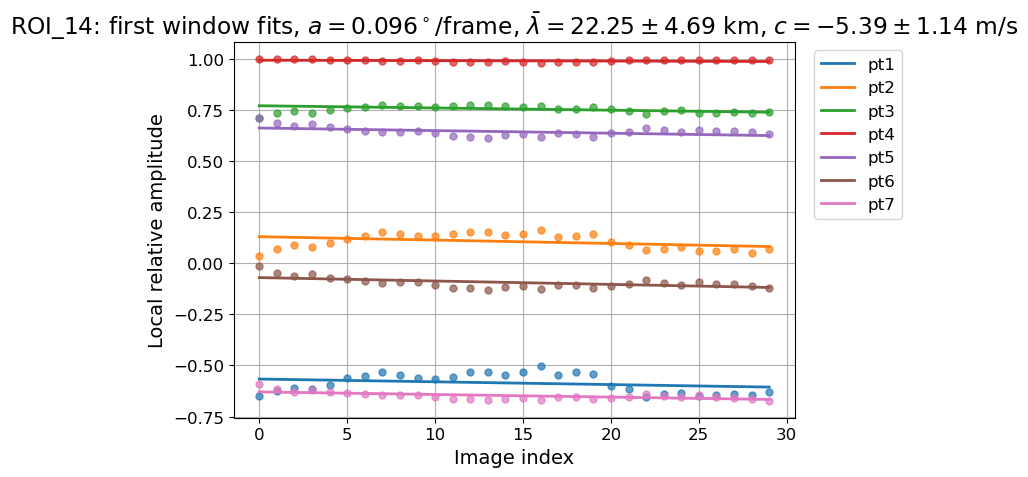


[ROI_14] Running-fit summary table:
 win  row_start  row_end a_deg/frame lambda_km lambda_err angle_deg angle_err  dir  c_m/s c_err
   0          0       29        0.10     22.25       4.69     73.15      7.34   -1  -5.39  1.14
   1          5       34        0.13     22.17       4.67     73.12      7.32    1   7.46  1.57
   2         10       39        0.12     22.09       4.65     73.09      7.30    1   6.74  1.42
   3         15       44        0.08     22.06       4.64     73.09      7.31    1   4.64  0.98
   4         20       49        0.28     22.05       4.64     73.10      7.32   -1 -15.43  3.25

OVERALL SUMMARY
   ROI a_deg/frame lambda_km lambda_err angle_deg angle_err  dir c_m/s c_err  SSE
ROI_14        0.11     22.18       4.68     73.13      7.35   -1 -6.07  1.28 0.41

Saved overall table:
  AWE\06326\remap85\awe_radiance_200km_box_interpolated_frames_cropped\overlays_crests_phase\phase_speed_tables\overall_phase_speed_summary.csv
  AWE\06326\remap85\awe_radiance_200km_b

In [12]:
# %%
from __future__ import annotations

from pathlib import Path
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Phase-speed fitting from PNG ROI CSV files
#
# This script is the phase-speed / cosine-fitting companion to the
# PNG ROI wavelet batch script.
#
# Expected current CSV format:
#   image_index,
#   wavelength_km,
#   wavelength_error_km,
#   angle_deg,
#   angle_error_deg,
#   pt1, pt2, ..., ptN
#
# Backward-compatible older CSV format:
#   image_index,
#   dominant_wavelength_km,
#   dominant_theta_deg,
#   pt1, pt2, ..., ptN
#
# What this script does:
#   - Finds all ROI folders automatically from:
#         FRAME_DIR / "overlays_crests_phase" / ROI_*
#     unless ONLY_ROIS is used.
#
#   - Reads local relative-amplitude values:
#         pt1, pt2, ..., ptN
#
#   - Fits the time evolution with:
#         y ≈ cos(a t + b)
#
#     where:
#         a = fitted phase shift in deg/frame
#         t = image_index
#         b = point-dependent phase offset
#
#   - Estimates propagation direction automatically from the fitted
#     phase offsets across points:
#         direction = -1 if phase slope > 0
#         direction = +1 otherwise
#
#   - Uses wavelength and wavelength_error_km from the CSV to compute:
#         c = lambda * f
#
#     where:
#         f = (a / 360) / DT_FRAME_S
#
#   - Combines wavelength uncertainty using:
#         combined_error = sqrt(frame_to_frame_spread^2 + mean(measurement_error^2))
#
#   - Reads angle_deg and angle_error_deg, summarizes them, and includes
#     them in the running-window table.
#
#   - Computes:
#         1) overall phase speed per ROI
#         2) running-window phase speed per ROI
#
# Notes:
#   - angle_deg is not directly used in c = lambda * f.
#   - It is included as a diagnostic for the selected wave orientation.
#   - If the CSV is the older format, wavelength_error_km and
#     angle_error_deg will be treated as missing.
# ============================================================


# -----------------------------
# User settings
# -----------------------------

# Folder with input PNG frames.
# This should match the same FRAME_DIR used in the PNG wavelet batch script.
FRAME_DIR = out_dir / "awe_radiance_200km_box_interpolated_frames_cropped"

# Save summary tables.
SAVE_TABLES = True
TABLE_OUTPUT_DIR: Optional[str] = None

# Optional explicit overlay folder.
# If None, uses:
#   FRAME_DIR / "overlays_crests_phase"
OVERLAY_DIR: Optional[str] = None

# Process all ROI folders automatically.
# To process only some ROIs, use names like:
#   ONLY_ROIS = ["ROI_56", "ROI_104"]
ONLY_ROIS: list[str] | None = None

# Seconds between PNG frames.
# Keep this consistent with how the PNG frames were generated.
DT_FRAME_S = 1.1

# Grid search setup.
# a0_deg is the initial guess for phase shift in deg/frame.
a0_deg = 20 / 60
f_min, f_max = 0.25, 4.0
n_trial = 201
n_b = 720

# Running-window settings.
# WINDOW is number of saved CSV rows, not necessarily raw frame number span.
WINDOW = 30
STEP = 5

# Plot controls.
MAKE_SSE_PLOT = True
MAKE_DATA_FIT_PLOT = True
MAKE_COS_SUMMARY_PLOT = True
MAKE_RUNNING_WINDOW_PLOTS = True
SHOW_FIRST_WINDOW_PLOTS = True


# -----------------------------
# Folder helpers
# -----------------------------
def get_overlay_base_dir() -> Path:
    frame_dir = Path(FRAME_DIR)

    if OVERLAY_DIR is not None:
        return Path(OVERLAY_DIR)

    return frame_dir / "overlays_crests_phase"


# -----------------------------
# Error helpers
# -----------------------------
def combine_mean_and_measurement_error(values, errors=None):
    """
    Combine frame-to-frame spread and per-frame measurement error.

    Returns:
        mean_value
        combined_error

    combined_error = sqrt(std(values)^2 + mean(error^2))

    This is a practical uncertainty estimate, not a full formal
    uncertainty propagation.
    """
    values = np.asarray(values, float)

    finite_v = values[np.isfinite(values)]

    if finite_v.size == 0:
        return np.nan, np.nan

    mean_value = float(np.nanmean(values))

    if finite_v.size > 1:
        spread = float(np.nanstd(values, ddof=1))
    else:
        spread = 0.0

    if errors is None:
        meas = 0.0
    else:
        errors = np.asarray(errors, float)
        finite_e = errors[np.isfinite(errors)]

        if finite_e.size > 0:
            meas = float(np.sqrt(np.nanmean(finite_e**2)))
        else:
            meas = 0.0

    combined_error = float(np.sqrt(spread**2 + meas**2))

    return mean_value, combined_error


# -----------------------------
# CSV loader
# -----------------------------
def load_roi_csv(csv_path: Path):
    """
    Load one ROI CSV.

    Current expected format:
        image_index,
        wavelength_km,
        wavelength_error_km,
        angle_deg,
        angle_error_deg,
        pt1, pt2, ..., ptN

    Older supported format:
        image_index,
        dominant_wavelength_km,
        dominant_theta_deg,
        pt1, pt2, ..., ptN
    """
    print("\n" + "=" * 80)
    print("Loading CSV from:", csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        header = f.readline().strip().split(",")

    header_clean = [h.strip() for h in header]
    header_lc = [h.lower() for h in header_clean]

    def _find_col(names, required: bool = True):
        if isinstance(names, str):
            names = [names]

        for name in names:
            name_lc = name.lower()
            if name_lc in header_lc:
                return header_lc.index(name_lc)

        if required:
            raise ValueError(f"Column '{names}' not found in CSV header: {header_clean}")

        return None

    col_t = _find_col("image_index", required=True)

    # Current weighted-column names.
    # Older names are kept as fallbacks so the script is less fragile.
    col_lam = _find_col(
        ["wavelength_km", "dominant_wavelength_km"],
        required=False,
    )
    col_lam_err = _find_col(
        ["wavelength_error_km", "wavelength_std_km", "wavelength_stdev_km"],
        required=False,
    )

    col_angle = _find_col(
        ["angle_deg", "dominant_theta_deg", "theta_deg"],
        required=False,
    )
    col_angle_err = _find_col(
        ["angle_error_deg", "angle_std_deg", "angle_stdev_deg", "theta_error_deg"],
        required=False,
    )

    metadata_cols = {
        c for c in [col_t, col_lam, col_lam_err, col_angle, col_angle_err]
        if c is not None
    }

    pt_cols = [
        i for i, h in enumerate(header_lc)
        if h.startswith("pt")
    ]

    if not pt_cols:
        # Fallback: any non-metadata column is assumed to be a point column.
        pt_cols = [
            i for i in range(len(header_lc))
            if i not in metadata_cols
        ]

    if not pt_cols:
        raise ValueError(f"No point columns found in CSV header: {header_clean}")

    pt_names = [header_clean[i] for i in pt_cols]

    data = np.genfromtxt(csv_path, delimiter=",", skip_header=1)

    if data.ndim == 1:
        data = data[None, :]

    t = data[:, col_t].astype(float)

    wavelength_km = data[:, col_lam].astype(float) if col_lam is not None else None
    wavelength_error_km = data[:, col_lam_err].astype(float) if col_lam_err is not None else None

    angle_deg = data[:, col_angle].astype(float) if col_angle is not None else None
    angle_error_deg = data[:, col_angle_err].astype(float) if col_angle_err is not None else None

    Y = data[:, pt_cols].astype(float)

    return (
        t,
        wavelength_km,
        wavelength_error_km,
        angle_deg,
        angle_error_deg,
        Y,
        pt_names,
    )


# -----------------------------
# Grid search: y ≈ cos(a t + b)
# -----------------------------
def fit_phase_grid_search(t, Y, pt_names, roi_name):
    """
    Fit one shared phase speed a and one phase offset b per point.
    """
    n_frames, n_pts = Y.shape

    base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    colors = [base_colors[j % len(base_colors)] for j in range(n_pts)]

    a_trial_deg = a0_deg * np.linspace(f_min, f_max, n_trial)
    a_trial = np.deg2rad(a_trial_deg)
    b_grid = np.linspace(0.0, 2.0 * np.pi, n_b, endpoint=False)

    errors = np.zeros(n_trial)

    for k, a_k in enumerate(a_trial):
        base_phase = a_k * t
        phase_mat = base_phase[:, None] + b_grid[None, :]
        cos_mat = np.cos(phase_mat)

        sse_total = 0.0

        for j in range(n_pts):
            y = Y[:, j][:, None]
            sse_b = np.sum((y - cos_mat) ** 2, axis=0)
            sse_total += np.min(sse_b)

        errors[k] = sse_total

    best_idx = int(np.argmin(errors))
    best_a = float(a_trial[best_idx])
    best_a_deg = float(a_trial_deg[best_idx])

    print(f"\n[{roi_name}] Best a = {best_a_deg:.6f} deg/frame")
    print(f"[{roi_name}] Initial a0 = {a0_deg:.6f} deg/frame")
    print(f"[{roi_name}] Factor = {best_a_deg / a0_deg:.3f}")
    print(f"[{roi_name}] SSE_min = {errors[best_idx]:.4f}")

    if MAKE_SSE_PLOT:
        plt.figure(figsize=(8, 4))
        plt.plot(a_trial_deg, errors, "-")
        plt.axvline(best_a_deg, color="r", linestyle="--", label="best a")
        plt.axvline(a0_deg, color="k", linestyle=":", label="initial a0")
        plt.xlabel("a (deg per frame)")
        plt.ylabel("Total SSE over all points")
        plt.title(f"{roi_name}: Grid search for phase speed a")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    b_best = np.zeros(n_pts)
    sse_per_point = np.zeros(n_pts)

    base_phase_best = best_a * t
    phase_mat_best = base_phase_best[:, None] + b_grid[None, :]
    cos_mat_best = np.cos(phase_mat_best)

    print(f"\n[{roi_name}] Per-point best phases:")

    for j in range(n_pts):
        y = Y[:, j][:, None]
        sse_b = np.sum((y - cos_mat_best) ** 2, axis=0)
        k_b = int(np.argmin(sse_b))

        b_best[j] = b_grid[k_b]
        sse_per_point[j] = sse_b[k_b]

        print(
            f"  {pt_names[j]}: b = {np.degrees(b_best[j]):.1f} deg, "
            f"SSE={sse_per_point[j]:.4f}"
        )

    if MAKE_DATA_FIT_PLOT:
        t_fine = np.linspace(t.min(), t.max(), 500)

        plt.figure(figsize=(10, 6))

        for j in range(n_pts):
            col = colors[j]

            plt.plot(t, Y[:, j], "o", ms=4, alpha=0.6, color=col)
            plt.plot(
                t_fine,
                np.cos(best_a * t_fine + b_best[j]),
                "-",
                lw=2,
                color=col,
                label=pt_names[j],
            )

        plt.xlabel("Image index")
        plt.ylabel("Local relative amplitude")
        plt.title(rf"{roi_name}: best $a = {best_a_deg:.3f}^\circ$/frame")
        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout(rect=[0, 0, 0.8, 1])
        plt.show()

    return best_a_deg, b_best, colors, n_pts, a_trial_deg, a_trial, b_grid, errors


# -----------------------------
# Direction and phase-speed helpers
# -----------------------------
def estimate_direction_from_phase(b_best):
    """
    Estimate propagation direction from phase offsets across sample points.

    The logic is intentionally kept simple:
        direction = -1 if phase slope > 0
        direction = +1 otherwise
    """
    b_unwrapped = np.unwrap(b_best)
    x_pts = np.arange(len(b_unwrapped))

    slope_rad = np.polyfit(x_pts, b_unwrapped, 1)[0]
    slope_deg = np.degrees(slope_rad)

    direction = -1 if slope_rad > 0 else 1

    return direction, slope_deg, b_unwrapped


def calculate_overall_phase_speed(
    best_a_deg,
    wavelength_km,
    wavelength_error_km=None,
    direction=1,
):
    """
    Calculate signed phase speed using ROI-mean wavelength.

    c = lambda * f

    where:
        f = (a / 360) / DT_FRAME_S
        a = best_a_deg in deg/frame
    """
    if wavelength_km is None:
        return np.nan, np.nan, np.nan, np.nan

    avg_wavelength_km, avg_wavelength_error_km = combine_mean_and_measurement_error(
        wavelength_km,
        wavelength_error_km,
    )

    speed_mps = 1000.0 * avg_wavelength_km * (best_a_deg / 360.0) / DT_FRAME_S

    speed_error_mps = (
        1000.0 * avg_wavelength_error_km * (best_a_deg / 360.0) / DT_FRAME_S
        if np.isfinite(avg_wavelength_error_km)
        else np.nan
    )

    speed_mps_signed = direction * speed_mps

    return avg_wavelength_km, avg_wavelength_error_km, speed_mps_signed, speed_error_mps


# -----------------------------
# Cosine summary plot
# -----------------------------
def make_single_cosine_summary_plot(roi_name, best_a_deg, b_best, colors, n_pts, t):
    """
    Plot one cosine and show the phase coverage of each tracked point.

    No manual shifting is used.
    The fitted b values are unwrapped and centered automatically.
    """
    direction, phase_slope_deg, b_unwrapped = estimate_direction_from_phase(b_best)

    phase_shift_per_frame_deg = direction * best_a_deg
    total_phase_span_deg = phase_shift_per_frame_deg * (len(t) - 1)

    print(f"\n[{roi_name}] Automatic direction = {direction}")
    print(f"[{roi_name}] Phase slope across points = {phase_slope_deg:.2f} deg/point")
    print(f"[{roi_name}] Phase shift per frame = {phase_shift_per_frame_deg:.6f} deg/frame")

    phi_deg = np.linspace(-360, 360, 2000)
    cos_phi = np.cos(np.radians(phi_deg))

    start_deg = np.degrees(b_unwrapped)

    # Center all starting phases near zero for a cleaner plot.
    center_phase = np.nanmean(start_deg)
    start_deg = start_deg - 360 * np.round(center_phase / 360)

    end_deg = start_deg + total_phase_span_deg

    if MAKE_COS_SUMMARY_PLOT:
        plt.figure(figsize=(10, 6))
        plt.plot(phi_deg, cos_phi, color="0.8", lw=2, label="cosine")

        for j in range(n_pts):
            c = colors[j]
            s0 = start_deg[j]
            s1 = end_deg[j]

            lo, hi = sorted((s0, s1))
            mask = (phi_deg >= lo) & (phi_deg <= hi)

            if np.any(mask):
                plt.plot(phi_deg[mask], cos_phi[mask], lw=3, color=c)

            y0 = np.cos(np.radians(s0))
            y1 = np.cos(np.radians(s1))

            if -360 <= s0 <= 360:
                plt.scatter([s0], [y0], color=c, zorder=4)
                plt.text(s0, y0, f"{j + 1}", fontsize=9, ha="center", va="bottom", color=c)

            if -360 <= s1 <= 360:
                plt.scatter([s1], [y1], color=c, zorder=4, marker="x")

        plt.xlabel("Phase (deg)")
        plt.ylabel("cos(phase)")
        plt.title(
            f"{roi_name}: Cosine phase coverage\n"
            f"direction = {direction}, phase slope = {phase_slope_deg:.2f} deg/point"
        )
        plt.xlim(-360, 360)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout(rect=[0, 0, 0.82, 1])
        plt.show()

    return direction, phase_slope_deg


# -----------------------------
# Running-window phase speed
# -----------------------------
def running_phase_speed(
    roi_name,
    t,
    Y,
    pt_names,
    wavelength_km,
    wavelength_error_km,
    angle_deg,
    angle_error_deg,
    colors,
    a_trial_deg,
    a_trial,
    b_grid,
):
    """
    Fit phase speed inside a moving time window.

    For each window:
        - refit best a
        - refit b per point
        - estimate direction from b slope
        - use window-mean wavelength
        - compute signed phase speed and its wavelength-based error
        - summarize window-mean angle
    """
    if wavelength_km is None:
        print(f"[{roi_name}] No wavelength column. Skipping running phase speed.")
        return None

    n_frames, n_pts = Y.shape

    if n_frames < WINDOW:
        print(f"[{roi_name}] Not enough frames for WINDOW={WINDOW}. Skipping running fit.")
        return None

    results = []
    n_windows = 1 + (n_frames - WINDOW) // STEP

    print(f"\n[{roi_name}] Running phase speed:")
    print(f"WINDOW={WINDOW}, STEP={STEP}, total windows={n_windows}")

    for w_idx, start in enumerate(range(0, n_frames - WINDOW + 1, STEP)):
        end = start + WINDOW

        t_w = t[start:end]
        Y_w = Y[start:end, :]

        lam_w_km = wavelength_km[start:end]
        lam_err_w_km = (
            wavelength_error_km[start:end]
            if wavelength_error_km is not None
            else None
        )

        angle_w_deg = (
            angle_deg[start:end]
            if angle_deg is not None
            else None
        )

        angle_err_w_deg = (
            angle_error_deg[start:end]
            if angle_error_deg is not None
            else None
        )

        lam_avg_km, lam_avg_err_km = combine_mean_and_measurement_error(
            lam_w_km,
            lam_err_w_km,
        )

        if angle_w_deg is not None:
            angle_avg_deg, angle_avg_err_deg = combine_mean_and_measurement_error(
                angle_w_deg,
                angle_err_w_deg,
            )
        else:
            angle_avg_deg, angle_avg_err_deg = np.nan, np.nan

        errors_w = np.zeros(len(a_trial), dtype=float)

        for k, a_k in enumerate(a_trial):
            base_phase = a_k * t_w
            phase_mat = base_phase[:, None] + b_grid[None, :]
            cos_mat = np.cos(phase_mat)

            sse_total = 0.0

            for j in range(n_pts):
                yj = Y_w[:, j][:, None]
                sse_b = np.sum((yj - cos_mat) ** 2, axis=0)
                sse_total += np.min(sse_b)

            errors_w[k] = sse_total

        best_k = int(np.argmin(errors_w))
        best_a_deg_w = float(a_trial_deg[best_k])
        best_a_w = float(a_trial[best_k])
        sse_min_w = float(errors_w[best_k])

        base_phase_best = best_a_w * t_w
        phase_mat_best = base_phase_best[:, None] + b_grid[None, :]
        cos_mat_best = np.cos(phase_mat_best)

        b_best_w = np.zeros(n_pts)

        for j in range(n_pts):
            yj = Y_w[:, j][:, None]
            sse_b = np.sum((yj - cos_mat_best) ** 2, axis=0)
            b_best_w[j] = b_grid[int(np.argmin(sse_b))]

        direction_w, phase_slope_deg_w, _ = estimate_direction_from_phase(b_best_w)

        if np.isfinite(lam_avg_km):
            phase_speed_mps = 1000.0 * lam_avg_km * (best_a_deg_w / 360.0) / DT_FRAME_S
            phase_speed_mps_signed = direction_w * phase_speed_mps
        else:
            phase_speed_mps_signed = np.nan

        if np.isfinite(lam_avg_err_km):
            phase_speed_err_mps = (
                1000.0 * lam_avg_err_km * (best_a_deg_w / 360.0) / DT_FRAME_S
            )
        else:
            phase_speed_err_mps = np.nan

        results.append({
            "roi": roi_name,
            "window_index": w_idx,
            "start_row": int(start),
            "end_row": int(end - 1),
            "start_frame": float(t_w[0]),
            "end_frame": float(t_w[-1]),
            "best_a_deg_per_frame": best_a_deg_w,
            "avg_wavelength_km": lam_avg_km,
            "avg_wavelength_error_km": lam_avg_err_km,
            "avg_angle_deg": angle_avg_deg,
            "avg_angle_error_deg": angle_avg_err_deg,
            "direction": int(direction_w),
            "phase_slope_deg_per_point": float(phase_slope_deg_w),
            "phase_speed_m_per_s": float(phase_speed_mps_signed),
            "phase_speed_error_m_per_s": float(phase_speed_err_mps),
            "SSE_min": sse_min_w,
        })

        if MAKE_RUNNING_WINDOW_PLOTS and SHOW_FIRST_WINDOW_PLOTS and w_idx == 0:
            print("\nFirst window only plots")
            print(f"Rows {start}..{end - 1}, frames {t_w[0]:.0f}..{t_w[-1]:.0f}")
            print(f"Best a = {best_a_deg_w:.4f} deg/frame")
            print(f"Avg λ = {lam_avg_km:.2f} ± {lam_avg_err_km:.2f} km")
            print(f"Avg angle = {angle_avg_deg:.2f} ± {angle_avg_err_deg:.2f} deg")
            print(f"Direction = {direction_w}")
            print(f"Phase slope = {phase_slope_deg_w:.2f} deg/point")
            print(f"Signed phase speed = {phase_speed_mps_signed:.2f} ± {phase_speed_err_mps:.2f} m/s")

            plt.figure(figsize=(8, 4))
            plt.plot(a_trial_deg, errors_w, "-")
            plt.axvline(best_a_deg_w, color="r", linestyle="--", label="best a")
            plt.xlabel("a (deg per frame)")
            plt.ylabel("Total SSE")
            plt.title(f"{roi_name}: Window 0 grid search")
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

            t_fine = np.linspace(t_w.min(), t_w.max(), 200)

            plt.figure(figsize=(10, 5))

            for j in range(n_pts):
                col = colors[j]

                plt.plot(t_w, Y_w[:, j], "o", ms=5, alpha=0.7, color=col)
                plt.plot(
                    t_fine,
                    np.cos(best_a_w * t_fine + b_best_w[j]),
                    "-",
                    lw=2,
                    color=col,
                    label=pt_names[j],
                )

            plt.xlabel("Image index")
            plt.ylabel("Local relative amplitude")
            plt.title(
                rf"{roi_name}: first window fits, "
                rf"$a = {best_a_deg_w:.3f}^\circ$/frame, "
                rf"$\bar{{\lambda}} = {lam_avg_km:.2f}\pm{lam_avg_err_km:.2f}$ km, "
                rf"$c = {phase_speed_mps_signed:.2f}\pm{phase_speed_err_mps:.2f}$ m/s"
            )
            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
            plt.tight_layout(rect=[0, 0, 0.8, 1])
            plt.show()

    print_running_window_table(roi_name, results)

    return results


def print_running_window_table(roi_name, results):
    """
    Print a compact running-window summary table.
    Uses pandas if available, otherwise falls back to plain dict printing.
    """
    try:
        import pandas as pd

        df = pd.DataFrame(results)

        df_show = df[[
            "window_index",
            "start_row",
            "end_row",
            "best_a_deg_per_frame",
            "avg_wavelength_km",
            "avg_wavelength_error_km",
            "avg_angle_deg",
            "avg_angle_error_deg",
            "direction",
            "phase_speed_m_per_s",
            "phase_speed_error_m_per_s",
        ]].copy()

        df_show.columns = [
            "win",
            "row_start",
            "row_end",
            "a_deg/frame",
            "lambda_km",
            "lambda_err",
            "angle_deg",
            "angle_err",
            "dir",
            "c_m/s",
            "c_err",
        ]

        for c in [
            "a_deg/frame",
            "lambda_km",
            "lambda_err",
            "angle_deg",
            "angle_err",
            "c_m/s",
            "c_err",
        ]:
            df_show[c] = df_show[c].map(lambda x: f"{x:.2f}" if np.isfinite(x) else "nan")

        print(f"\n[{roi_name}] Running-fit summary table:")
        print(df_show.to_string(index=False))

    except Exception:
        print(f"\n[{roi_name}] Running-fit summary table:")

        for r in results:
            print(r)


# -----------------------------
# Main
# -----------------------------
overlay_base = get_overlay_base_dir()

roi_csvs = sorted(overlay_base.glob("*/crest_relative_amplitude_evolution.csv"))

if ONLY_ROIS is not None:
    only_set = set(ONLY_ROIS)
    roi_csvs = [p for p in roi_csvs if p.parent.name in only_set]

if not roi_csvs:
    raise FileNotFoundError(
        f"No ROI CSVs found in:\n  {overlay_base}\n"
        "Make sure the PNG wavelet batch script finished and created ROI subfolders."
    )

print("Overlay base:", overlay_base)
print(f"DT between frames = {DT_FRAME_S:.3f} s")
print(f"Initial a0 = {a0_deg:.6f} deg/frame")
print("Found ROI CSVs:")

for p in roi_csvs:
    print(" ", p.parent.name)

overall_results = []
all_running_results = []

for csv_path in roi_csvs:
    roi_name = csv_path.parent.name

    (
        t,
        wavelength_km,
        wavelength_error_km,
        angle_deg,
        angle_error_deg,
        Y,
        pt_names,
    ) = load_roi_csv(csv_path)

    print(f"[{roi_name}] Data shape (frames, points): {Y.shape}")

    if wavelength_km is not None:
        print(
            f"[{roi_name}] Wavelength stats (km): "
            f"min={np.nanmin(wavelength_km):.2f}, "
            f"median={np.nanmedian(wavelength_km):.2f}, "
            f"max={np.nanmax(wavelength_km):.2f}"
        )

    if wavelength_error_km is not None:
        print(
            f"[{roi_name}] Wavelength error stats (km): "
            f"median={np.nanmedian(wavelength_error_km):.2f}, "
            f"max={np.nanmax(wavelength_error_km):.2f}"
        )
    else:
        print(f"[{roi_name}] No wavelength_error_km column found.")

    if angle_deg is not None:
        print(
            f"[{roi_name}] Angle stats (deg): "
            f"min={np.nanmin(angle_deg):.2f}, "
            f"median={np.nanmedian(angle_deg):.2f}, "
            f"max={np.nanmax(angle_deg):.2f}"
        )

    if angle_error_deg is not None:
        print(
            f"[{roi_name}] Angle error stats (deg): "
            f"median={np.nanmedian(angle_error_deg):.2f}, "
            f"max={np.nanmax(angle_error_deg):.2f}"
        )
    else:
        print(f"[{roi_name}] No angle_error_deg column found.")

    (
        best_a_deg,
        b_best,
        colors,
        n_pts,
        a_trial_deg,
        a_trial,
        b_grid,
        errors,
    ) = fit_phase_grid_search(
        t=t,
        Y=Y,
        pt_names=pt_names,
        roi_name=roi_name,
    )

    direction, phase_slope_deg = make_single_cosine_summary_plot(
        roi_name=roi_name,
        best_a_deg=best_a_deg,
        b_best=b_best,
        colors=colors,
        n_pts=n_pts,
        t=t,
    )

    (
        avg_wavelength_km,
        avg_wavelength_error_km,
        overall_phase_speed_mps,
        overall_phase_speed_error_mps,
    ) = calculate_overall_phase_speed(
        best_a_deg=best_a_deg,
        wavelength_km=wavelength_km,
        wavelength_error_km=wavelength_error_km,
        direction=direction,
    )

    if angle_deg is not None:
        avg_angle_deg, avg_angle_error_deg = combine_mean_and_measurement_error(
            angle_deg,
            angle_error_deg,
        )
    else:
        avg_angle_deg, avg_angle_error_deg = np.nan, np.nan

    print(f"\n[{roi_name}] Overall phase speed:")
    print(f"  avg wavelength = {avg_wavelength_km:.2f} ± {avg_wavelength_error_km:.2f} km")
    print(f"  avg angle = {avg_angle_deg:.2f} ± {avg_angle_error_deg:.2f} deg")
    print(f"  best a = {best_a_deg:.6f} deg/frame")
    print(f"  direction = {direction}")
    print(f"  phase slope = {phase_slope_deg:.2f} deg/point")
    print(f"  phase speed = {overall_phase_speed_mps:.2f} ± {overall_phase_speed_error_mps:.2f} m/s")

    overall_results.append({
        "roi": roi_name,
        "best_a_deg_per_frame": float(best_a_deg),
        "avg_wavelength_km": float(avg_wavelength_km),
        "avg_wavelength_error_km": float(avg_wavelength_error_km),
        "avg_angle_deg": float(avg_angle_deg),
        "avg_angle_error_deg": float(avg_angle_error_deg),
        "direction": int(direction),
        "phase_slope_deg_per_point": float(phase_slope_deg),
        "phase_speed_m_per_s": float(overall_phase_speed_mps),
        "phase_speed_error_m_per_s": float(overall_phase_speed_error_mps),
        "SSE_min": float(np.nanmin(errors)),
    })

    running_results = running_phase_speed(
        roi_name=roi_name,
        t=t,
        Y=Y,
        pt_names=pt_names,
        wavelength_km=wavelength_km,
        wavelength_error_km=wavelength_error_km,
        angle_deg=angle_deg,
        angle_error_deg=angle_error_deg,
        colors=colors,
        a_trial_deg=a_trial_deg,
        a_trial=a_trial,
        b_grid=b_grid,
    )

    if running_results is not None:
        all_running_results.extend(running_results)


# -----------------------------
# Final compact summary + save tables
# -----------------------------
print("\n" + "=" * 80)
print("OVERALL SUMMARY")
print("=" * 80)

try:
    import pandas as pd

    # Default save location:
    #   FRAME_DIR / "overlays_crests_phase" / "phase_speed_tables"
    if TABLE_OUTPUT_DIR is None:
        table_dir = overlay_base / "phase_speed_tables"
    else:
        table_dir = Path(TABLE_OUTPUT_DIR)

    if SAVE_TABLES:
        table_dir.mkdir(parents=True, exist_ok=True)

    df_overall = pd.DataFrame(overall_results)

    df_show = df_overall[[
        "roi",
        "best_a_deg_per_frame",
        "avg_wavelength_km",
        "avg_wavelength_error_km",
        "avg_angle_deg",
        "avg_angle_error_deg",
        "direction",
        "phase_speed_m_per_s",
        "phase_speed_error_m_per_s",
        "SSE_min",
    ]].copy()

    df_show.columns = [
        "ROI",
        "a_deg/frame",
        "lambda_km",
        "lambda_err",
        "angle_deg",
        "angle_err",
        "dir",
        "c_m/s",
        "c_err",
        "SSE",
    ]

    for c in [
        "a_deg/frame",
        "lambda_km",
        "lambda_err",
        "angle_deg",
        "angle_err",
        "c_m/s",
        "c_err",
        "SSE",
    ]:
        df_show[c] = df_show[c].map(lambda x: f"{x:.2f}" if np.isfinite(float(x)) else "nan")

    print(df_show.to_string(index=False))

    if SAVE_TABLES:
        overall_csv = table_dir / "overall_phase_speed_summary.csv"
        overall_txt = table_dir / "overall_phase_speed_summary.txt"

        df_overall.to_csv(overall_csv, index=False)

        with open(overall_txt, "w") as f:
            f.write(df_show.to_string(index=False))

        print(f"\nSaved overall table:")
        print(f"  {overall_csv}")
        print(f"  {overall_txt}")

    if SAVE_TABLES and all_running_results:
        df_running = pd.DataFrame(all_running_results)

        running_csv = table_dir / "running_window_phase_speed_summary.csv"
        running_txt = table_dir / "running_window_phase_speed_summary.txt"

        df_running.to_csv(running_csv, index=False)

        df_running_show = df_running[[
            "roi",
            "window_index",
            "start_row",
            "end_row",
            "start_frame",
            "end_frame",
            "best_a_deg_per_frame",
            "avg_wavelength_km",
            "avg_wavelength_error_km",
            "avg_angle_deg",
            "avg_angle_error_deg",
            "direction",
            "phase_speed_m_per_s",
            "phase_speed_error_m_per_s",
            "SSE_min",
        ]].copy()

        with open(running_txt, "w") as f:
            f.write(df_running_show.to_string(index=False))

        print(f"\nSaved running-window table:")
        print(f"  {running_csv}")
        print(f"  {running_txt}")

except Exception as e:
    print("Could not create/save pandas tables.")
    print("Error:", e)

    for r in overall_results:
        print(
            f"{r['roi']}: "
            f"a={r['best_a_deg_per_frame']:.4f} deg/frame, "
            f"lambda={r['avg_wavelength_km']:.2f}±{r['avg_wavelength_error_km']:.2f} km, "
            f"angle={r['avg_angle_deg']:.2f}±{r['avg_angle_error_deg']:.2f} deg, "
            f"dir={r['direction']}, "
            f"c={r['phase_speed_m_per_s']:.2f}±{r['phase_speed_error_m_per_s']:.2f} m/s, "
            f"SSE={r['SSE_min']:.3f}"
        )